In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline

# Sample DataFrame: 5 regions × 6 months of sales data
df_sales = pd.DataFrame({
    'region': ['North', 'South', 'East', 'West', 'Central'],
    'jan': [12400, 9800, 15200, 8700, 11300],
    'feb': [13100, 10500, 14800, 9200, 12100],
    'mar': [14500, 11200, 16300, 10100, 13400],
    'apr': [13800, 10900, 15700, 9600, 12800],
    'may': [15200, 11800, 17100, 10400, 14200],
    'jun': [16000, 12400, 18500, 11000, 15600]
})

months_cols = ['jan', 'feb', 'mar', 'apr', 'may', 'jun']

df_sales['total_sales'] = df_sales[months_cols].sum(axis=1)

df_sales

,region,jan,feb,mar,apr,may,jun,total_sales
0,North,12400,13100,14500,13800,15200,16000,85000
1,South,9800,10500,11200,10900,11800,12400,66600
2,East,15200,14800,16300,15700,17100,18500,97600
3,West,8700,9200,10100,9600,10400,11000,59000
4,Central,11300,12100,13400,12800,14200,15600,79400


## Exercise 1 — Single Line Chart: East Region

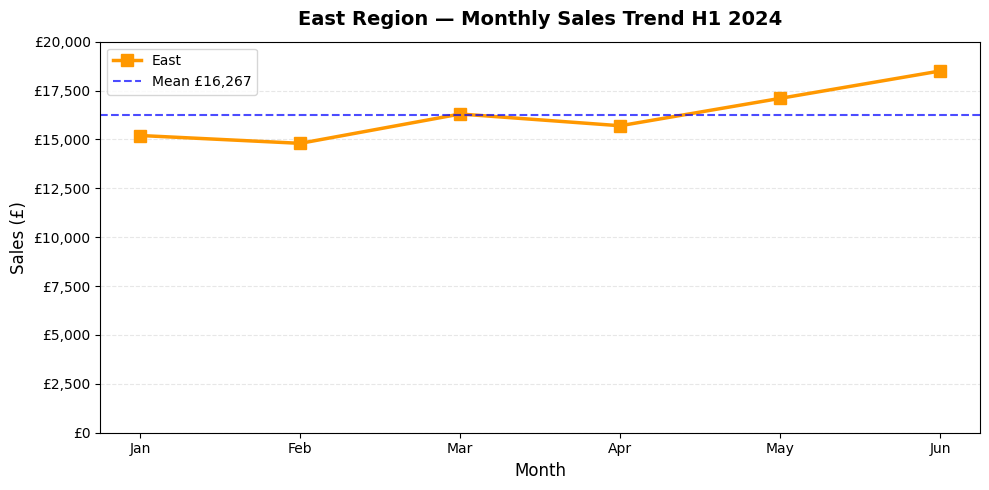

In [3]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

east = df_sales.loc[df_sales['region'] == 'East', months_cols].values[0].tolist()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    months,
    east,
    color='#FF9800',
    linewidth=2.5,
    marker='s',
    markersize=8,
    markerfacecolor='#FF9800',
    markeredgecolor='#FF9800',
    linestyle='-',
    label='East'
)

mean_val = sum(east) / len(east)

ax.axhline(
    mean_val,
    color='blue',
    linestyle='--',
    alpha=0.7,
    label=f'Mean £{mean_val:,.0f}'
)

ax.set_title('East Region — Monthly Sales Trend H1 2024',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Sales (£)', fontsize=12)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

ax.set_ylim(0, 20000)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend()

plt.tight_layout()
plt.show()

## Exercise 2 — Multi-Line Chart: North, East, and South

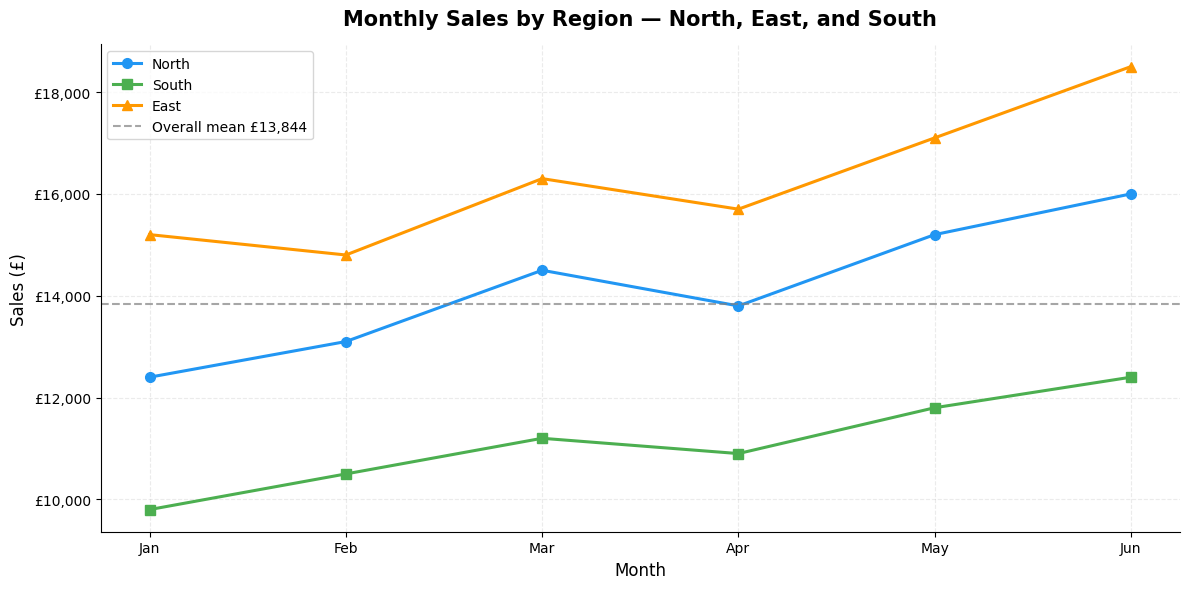

In [4]:
df_top = df_sales[df_sales['region'].isin(['North', 'East', 'South'])]

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

colour_map = {
    'North': '#2196F3',
    'East': '#FF9800',
    'South': '#4CAF50'
}

marker_map = {
    'North': 'o',
    'East': '^',
    'South': 's'
}

fig, ax = plt.subplots(figsize=(12, 6))

for i, row in df_top.iterrows():
    ax.plot(
        months,
        row[months_cols],
        color=colour_map[row['region']],
        marker=marker_map[row['region']],
        linewidth=2.2,
        markersize=7,
        label=row['region']
    )

overall_mean = df_top[months_cols].values.mean()

ax.axhline(
    overall_mean,
    color='gray',
    linestyle='--',
    alpha=0.7,
    label=f'Overall mean £{overall_mean:,.0f}'
)

ax.set_title('Monthly Sales by Region — North, East, and South',
             fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Sales (£)', fontsize=12)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

ax.legend(loc='upper left')
ax.grid(alpha=0.25, linestyle='--')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Exercise 3 — Horizontal Bar Chart: Ranked Lowest to Highest

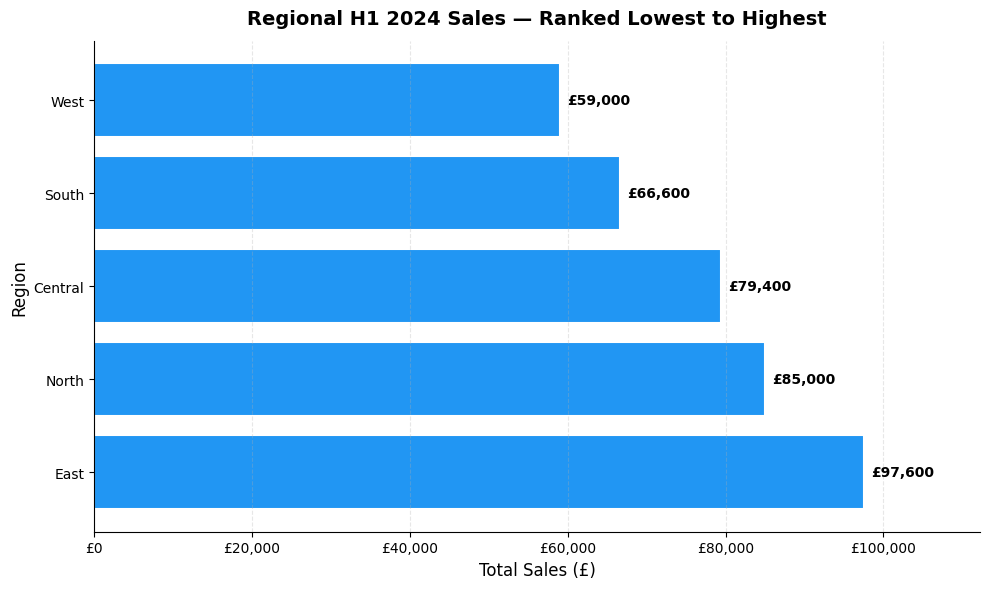

In [5]:
df_sorted = df_sales.sort_values('total_sales', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_sorted['region'],
    df_sorted['total_sales'],
    color='#2196F3',
    edgecolor='white',
    linewidth=1.5
)

ax.bar_label(
    bars,
    labels=[f'£{value:,.0f}' for value in df_sorted['total_sales']],
    padding=5,
    fontsize=10,
    fontweight='bold'
)

ax.set_title('Regional H1 2024 Sales — Ranked Lowest to Highest',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Total Sales (£)', fontsize=12)
ax.set_ylabel('Region', fontsize=12)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

ax.set_xlim(0, df_sorted['total_sales'].max() * 1.15)

# Makes the lowest value appear at the top
ax.invert_yaxis()

ax.grid(axis='x', alpha=0.3, linestyle='--')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Exercise 4 — Pie Chart: Q1 Sales Share

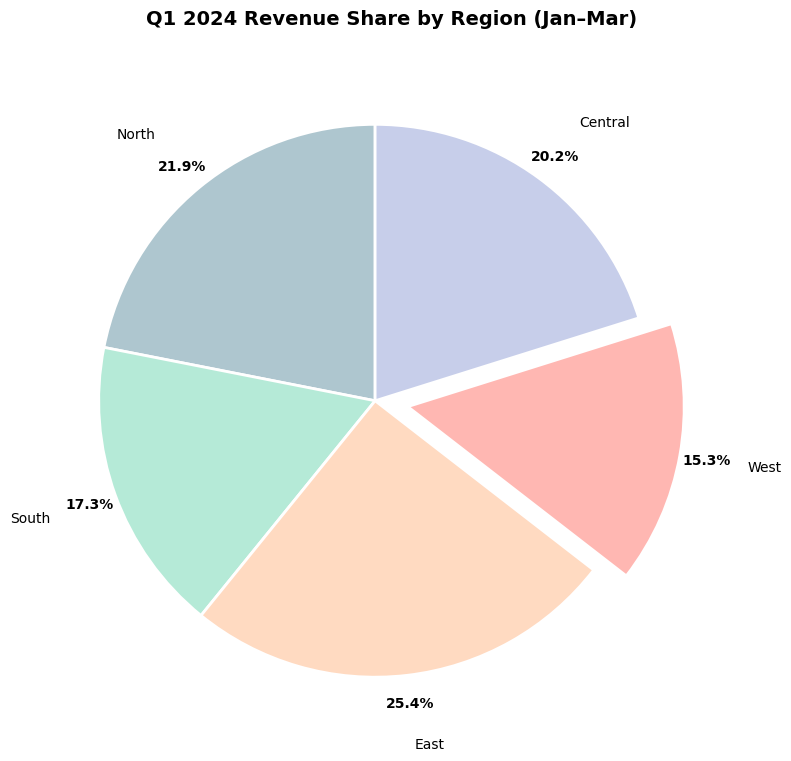

In [6]:
df_sales['q1_sales'] = df_sales[['jan', 'feb', 'mar']].sum(axis=1)

pastel_colours = ['#AEC6CF', '#B5EAD7', '#FFDAC1', '#FFB7B2', '#C7CEEA']

# West is the 4th row in the DataFrame, so its explode value is 0.12
explode = [0, 0, 0, 0.12, 0]

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    df_sales['q1_sales'],
    labels=df_sales['region'],
    autopct='%1.1f%%',
    pctdistance=1.1,
    labeldistance=1.25,
    colors=pastel_colours,
    explode=explode,
    startangle=90,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'}
)

for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('black')

ax.set_title('Q1 2024 Revenue Share by Region (Jan–Mar)',
             fontsize=14, fontweight='bold', pad=20)

plt.axis('equal')

plt.tight_layout()
plt.show()

## Exercise 5 — Scatter Plot: March vs June Sales

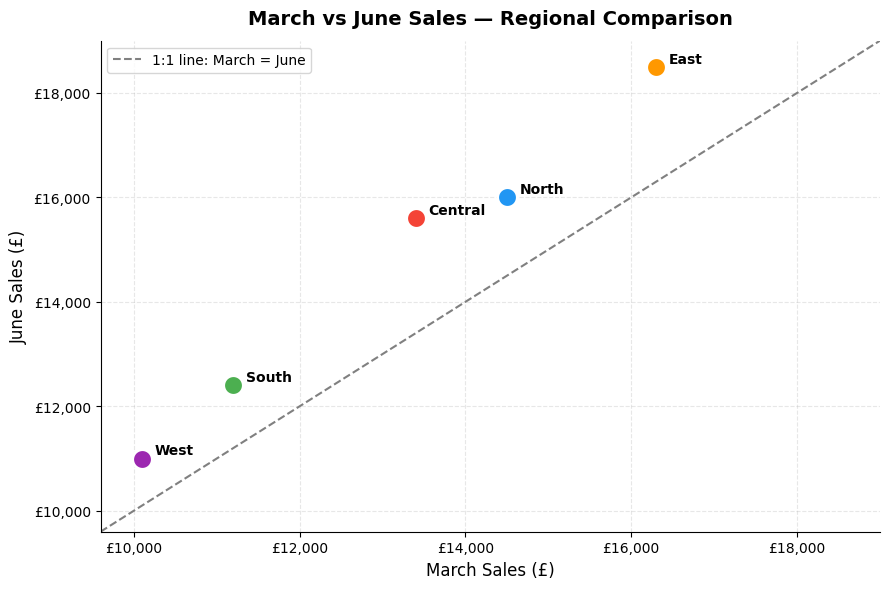

In [7]:
colours = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

fig, ax = plt.subplots(figsize=(9, 6))

for i, row in df_sales.iterrows():
    ax.scatter(
        row['mar'],
        row['jun'],
        color=colours[i],
        s=200,
        edgecolors='white',
        linewidths=2,
        zorder=5
    )
    
    ax.annotate(
        row['region'],
        xy=(row['mar'], row['jun']),
        textcoords='offset points',
        xytext=(9, 3),
        fontsize=10,
        fontweight='bold'
    )

min_val = min(df_sales['mar'].min(), df_sales['jun'].min()) - 500
max_val = max(df_sales['mar'].max(), df_sales['jun'].max()) + 500

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='gray',
    linestyle='--',
    label='1:1 line: March = June'
)

ax.set_title('March vs June Sales — Regional Comparison',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('March Sales (£)', fontsize=12)
ax.set_ylabel('June Sales (£)', fontsize=12)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

ax.grid(alpha=0.3, linestyle='--')
ax.legend()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Final Exercise 6 — Complete Dashboard

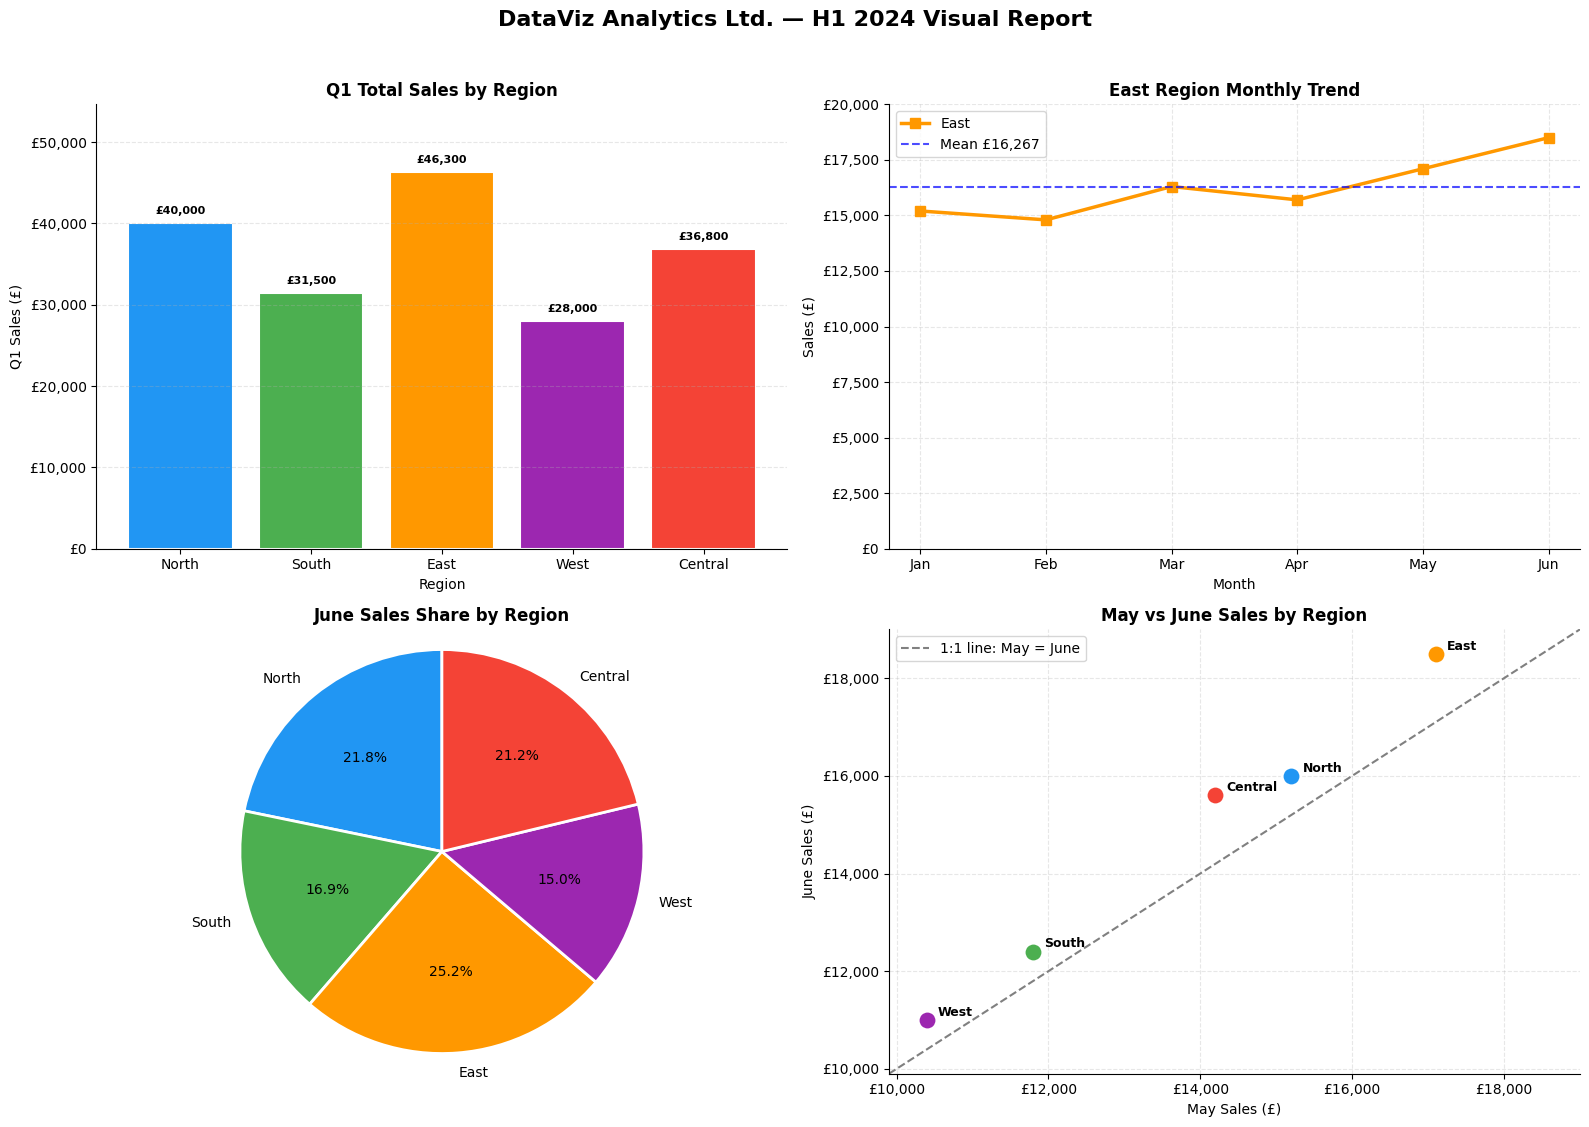

In [8]:
df_sales['q1_sales'] = df_sales[['jan', 'feb', 'mar']].sum(axis=1)

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
colours = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

ax1, ax2, ax3, ax4 = axes.flatten()

# TOP LEFT — Bar Chart: Q1 total sales per region
bars = ax1.bar(
    df_sales['region'],
    df_sales['q1_sales'],
    color=colours,
    edgecolor='white',
    linewidth=1.5
)

ax1.bar_label(
    bars,
    labels=[f'£{value:,.0f}' for value in df_sales['q1_sales']],
    padding=5,
    fontsize=8,
    fontweight='bold'
)

ax1.set_title('Q1 Total Sales by Region', fontweight='bold')
ax1.set_xlabel('Region')
ax1.set_ylabel('Q1 Sales (£)')
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)
ax1.set_ylim(0, df_sales['q1_sales'].max() * 1.18)
ax1.grid(axis='y', alpha=0.3, linestyle='--')


# TOP RIGHT — Line Chart: East region monthly trend with mean line
east = df_sales.loc[df_sales['region'] == 'East', months_cols].values[0].tolist()
east_mean = sum(east) / len(east)

ax2.plot(
    months,
    east,
    color='#FF9800',
    marker='s',
    linewidth=2.5,
    markersize=7,
    label='East'
)

ax2.axhline(
    east_mean,
    color='blue',
    linestyle='--',
    alpha=0.7,
    label=f'Mean £{east_mean:,.0f}'
)

ax2.set_title('East Region Monthly Trend', fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Sales (£)')
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)
ax2.set_ylim(0, 20000)
ax2.grid(alpha=0.3, linestyle='--')
ax2.legend()


# BOTTOM LEFT — Pie Chart: June sales share
ax3.pie(
    df_sales['jun'],
    labels=df_sales['region'],
    autopct='%1.1f%%',
    colors=colours,
    startangle=90,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'}
)

ax3.set_title('June Sales Share by Region', fontweight='bold')
ax3.axis('equal')


# BOTTOM RIGHT — Scatter Plot: May sales vs June sales
for i, row in df_sales.iterrows():
    ax4.scatter(
        row['may'],
        row['jun'],
        color=colours[i],
        s=180,
        edgecolors='white',
        linewidths=2,
        zorder=5
    )
    
    ax4.annotate(
        row['region'],
        xy=(row['may'], row['jun']),
        textcoords='offset points',
        xytext=(8, 3),
        fontsize=9,
        fontweight='bold'
    )

min_val = min(df_sales['may'].min(), df_sales['jun'].min()) - 500
max_val = max(df_sales['may'].max(), df_sales['jun'].max()) + 500

ax4.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='gray',
    linestyle='--',
    label='1:1 line: May = June'
)

ax4.set_title('May vs June Sales by Region', fontweight='bold')
ax4.set_xlabel('May Sales (£)')
ax4.set_ylabel('June Sales (£)')

ax4.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

ax4.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

ax4.set_xlim(min_val, max_val)
ax4.set_ylim(min_val, max_val)
ax4.grid(alpha=0.3, linestyle='--')
ax4.legend()


# Hide top and right spines for a cleaner dashboard
for ax in [ax1, ax2, ax4]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


plt.suptitle('DataViz Analytics Ltd. — H1 2024 Visual Report',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()

plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')

plt.show()